In [118]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from aux_functions import make_fitting_func, fit_curve, shorten_points, sort_experiments_by_freq
from treament_tcspc_data import extract_data_info_from_path, fetch_data_filenames, get_fft, get_fund_freq_and_amp, get_modulus_angle_unc

In [119]:
filenames_all = fetch_data_filenames("./sandbox")

exc_data_npy = [extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)]
data_txt = [extract_data_info_from_path(data_path_txt) for data_path_txt in filenames_all if ("step" in data_path_txt) and (".txt" in data_path_txt) and ("p10_" in data_path_txt)]
data_npy = [extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("p10_" in data_path_npy)]

freq_list = [1, 10, 100, 1000, 10000]
filtered_data = [d for d in data_npy if d["freq"] in freq_list]
filtered_exc_data = [d for d in exc_data_npy if d["freq"] in freq_list]
exc_data = sort_experiments_by_freq(filtered_exc_data)

1.7645174107618329
101.09940051400488


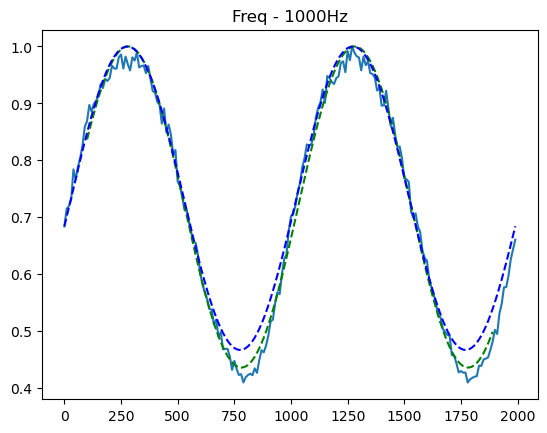

In [120]:
idx = 3
freq = filtered_data[idx]["freq"]
data_arr = np.array(filtered_data[idx]["data"])
xs = data_arr[:,:200,0].mean(axis=0)
ys = data_arr[:,:200,1].mean(axis=0)

lum_curve = np.column_stack((xs,ys))

plt.plot(lum_curve[:,0], lum_curve[:,1]/np.max(lum_curve[:,1]))
plt.title(f"Freq - {freq}Hz")
# plt.show()

omega = 2 * np.pi * freq*1e-6  # Convertendo freq de Hz para rad/µs

fitting_func = make_fitting_func(omega)

# Bounds for fitting
# exc_bounds=(
#     [0, 0, -np.pi], 
#     [1.5*(max(exc_curve[:,1])-min(exc_curve[:,1]))/2, 
#      1.5*(max(exc_curve[:,1])+min(exc_curve[:,1]))/2, 
#      np.pi] #A, A0, phi
#     )

lum_bounds=(
    [0, 0, 0], 
    [1.5*(max(lum_curve[:,1])-min(lum_curve[:,1]))/2, 
     1.5*(max(lum_curve[:,1])+min(lum_curve[:,1]))/2, 
     np.pi] #A, A0, phi
    )
# xs_exc, popt_exc = fit_curve(exc_curve, fitting_func, p0=p0, bounds=exc_bounds)
xs_lum, popt_lum = fit_curve(lum_curve, fitting_func, p0=None, bounds=lum_bounds)

plt.plot(xs_lum, fitting_func(xs_lum, *popt_lum)/np.max(fitting_func(xs_lum, *popt_lum)), "g--")
print(f"{popt_lum[2]}")
print(f"{np.degrees(popt_lum[2])}")

## FFT
xf, yf = get_fft(lum_curve[:,0],lum_curve[:,1])

mask = xf>0
xf = xf[mask]
yf = yf[mask]

idx_fund_freq = np.where(np.abs(yf) == np.abs(yf).max())[0][0] if len(np.where(np.abs(yf) == np.abs(yf).max())[0]) == 1 else None
omega_fft, angle_fft = xf[idx_fund_freq], np.angle(yf[idx_fund_freq])

ts = lum_curve[:,0]
ys = 1.1+.4*np.cos(2*np.pi*omega_fft*(1e-6)*ts+angle_fft)
# print(ts)

plt.plot(ts, ys/ys.max(), "b--")

plt.show()